# Simple Vision Example End to End

In this notebook we will build a small PyTorch computer vision pipeline from start to finish: load image data, define a CNN, train it, evaluate it, and inspect predictions.

In [1]:
import random

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(42)
random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 1. Load a small vision dataset

We will use MNIST and keep only a subset so the notebook trains quickly on CPU.

In [2]:
transform = transforms.ToTensor()

train_dataset_full = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset_full = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_dataset = Subset(train_dataset_full, range(5000))
test_dataset = Subset(test_dataset_full, range(1000))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class_names = [str(i) for i in range(10)]

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {class_names}")

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 65.5k/9.91M [00:00<00:19, 505kB/s]

  1%|▏         | 131k/9.91M [00:00<00:33, 292kB/s] 

  2%|▏         | 197k/9.91M [00:00<00:35, 274kB/s]

  4%|▍         | 393k/9.91M [00:00<00:20, 458kB/s]

...

 99%|█████████▉| 1.64M/1.65M [00:08<00:00, 174kB/s]

100%|██████████| 1.65M/1.65M [00:08<00:00, 194kB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 1.49MB/s]

Train samples: 5000
Test samples: 1000
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


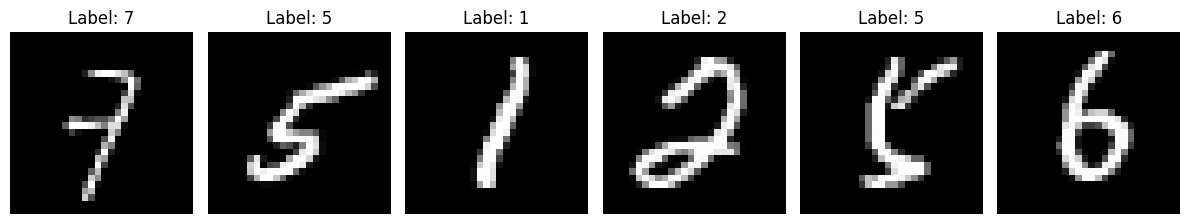

In [3]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for idx, ax in enumerate(axes):
    ax.imshow(images[idx].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[idx].item()}")
    ax.axis("off")

plt.tight_layout()

## 2. Define a simple CNN

This is a compact convolutional network that can learn MNIST quickly without needing a GPU.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


model = SimpleCNN().to(device)
sample_logits = model(images[:8].to(device))

print(model)
print(f"Sample logits shape: {sample_logits.shape}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=784, out_features=10, bias=True)
)
Sample logits shape: torch.Size([8, 10])


## 3. Train and evaluate the model

In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 3


def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item()


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy_from_logits(logits, labels)

    return running_loss / len(loader), running_acc / len(loader)


def evaluate(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0

    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = loss_fn(logits, labels)

            running_loss += loss.item()
            running_acc += accuracy_from_logits(logits, labels)

    return running_loss / len(loader), running_acc / len(loader)

In [6]:
history = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)

    history.append(
        {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
        }
    )

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f}"
    )

Epoch 1/3 | train_loss=1.4878 | train_acc=0.5761 | test_loss=0.6379 | test_acc=0.7809


Epoch 2/3 | train_loss=0.4290 | train_acc=0.8754 | test_loss=0.3901 | test_acc=0.8771


Epoch 3/3 | train_loss=0.2935 | train_acc=0.9152 | test_loss=0.2952 | test_acc=0.9104


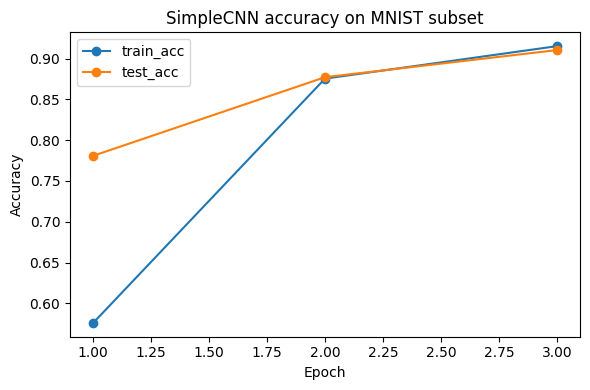

In [7]:
epochs_logged = [item["epoch"] for item in history]
train_accs = [item["train_acc"] for item in history]
test_accs = [item["test_acc"] for item in history]

plt.figure(figsize=(6, 4))
plt.plot(epochs_logged, train_accs, marker="o", label="train_acc")
plt.plot(epochs_logged, test_accs, marker="o", label="test_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SimpleCNN accuracy on MNIST subset")
plt.legend()
plt.tight_layout()

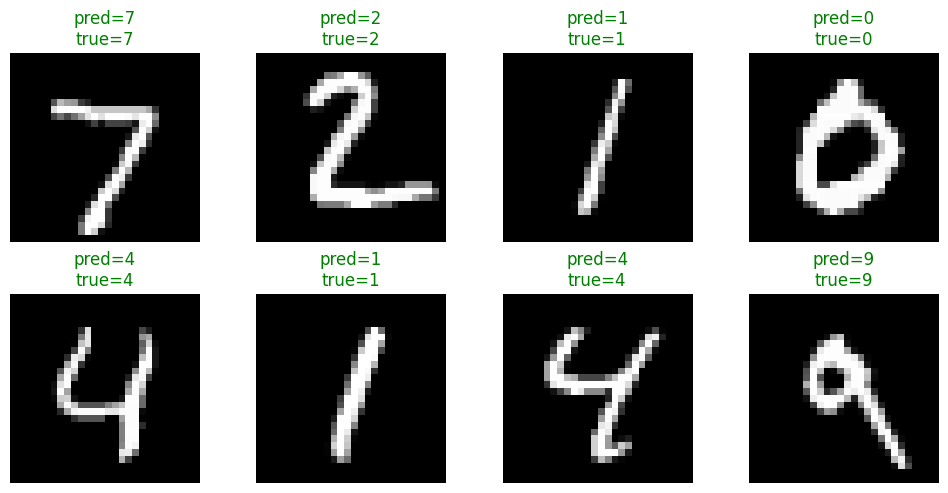

In [8]:
test_images, test_labels = next(iter(test_loader))
test_images, test_labels = test_images.to(device), test_labels.to(device)

with torch.inference_mode():
    test_logits = model(test_images)
    test_predictions = test_logits.argmax(dim=1)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(test_images[idx].cpu().squeeze(), cmap="gray")
    ax.set_title(
        f"pred={test_predictions[idx].item()}\ntrue={test_labels[idx].item()}",
        color="green" if test_predictions[idx] == test_labels[idx] else "red",
    )
    ax.axis("off")

plt.tight_layout()

## Wrap-up

This notebook covered the full PyTorch vision workflow on a small MNIST subset:

- loading image data with `torchvision.datasets`,
- batching it with a `DataLoader`,
- defining a compact CNN with `nn.Module`,
- training and evaluating with the standard optimizer/loss loop,
- and inspecting real predictions at the end.